# Imports

In [1]:
import pandas as pd
import plotly.graph_objects as go
import json
import numpy as np
import boto3
import base64
import httpx
from opensearchpy import OpenSearch, RequestsHttpConnection, AWSV4SignerAuth
from opensearchpy.helpers import bulk

In [2]:
DATA_DIR = "../Data/"
FILE_NAME = "data.jsonl"
OPENSEARCH_ENDPOINT = "https://search-bshgrag-db-fzguhm6xbhftvsxrphne6jnnpe.eu-central-1.es.amazonaws.com"
MAIN_INDEX_NAME = "products_main"
IMAGE_INDEX_NAME = "products_images"
AGENT_MODEL = "eu.amazon.nova-lite-v1:0"

In [3]:
bedrock = boto3.client(
    service_name="bedrock-runtime",
    region_name="eu-central-1"
)

# Data Loading

In [4]:
with open(DATA_DIR + FILE_NAME, encoding="utf-16") as f:
    data = [json.loads(line) for line in f if line.strip()]
df = pd.DataFrame(data)

# Data Analysis & Cleaning

#### Data Size

In [5]:
print(f"Total Rows in data: {df.shape[0]}")
print(f"Total Features in data: {df.shape[1]}")

Total Rows in data: 1500
Total Features in data: 14


#### Missing Data Analysis

First we analyze how much of our data is missing, in order to consider this, we first need to process our data such that empty lists are also considered as null values for the following columns:
- **features**
- **descriptioin**
- **images**
- **videos**
- **categories**
- **details** (empty object/dictionary)

In [6]:
df[["features", "description", "images", "videos", "categories"]] = df[["features", "description", "images", "videos", "categories"]].apply(lambda ser: ser.apply(lambda x: np.nan if x == [] else x))

df["details"] = df["details"].apply(lambda x: np.nan if x == {} else x)

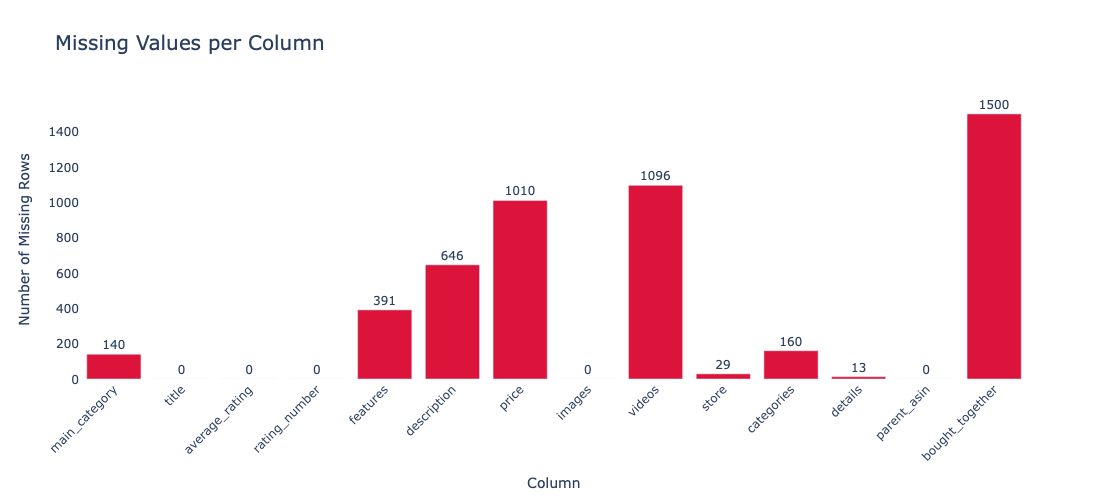

In [7]:
missing = df.isna().sum()

fig = go.Figure()

fig.add_trace(go.Bar(
    x=missing.index.tolist(),
    y=missing.values.tolist(),
    marker=dict(color="crimson"),
    text=missing.values.tolist(),
    textposition="outside",
    hovertemplate="<b>%{x}</b><br>Missing rows: %{y}<extra></extra>",
))

fig.update_layout(
    title=dict(text="Missing Values per Column", font=dict(size=20)),
    xaxis=dict(title="Column", tickangle=-45),
    yaxis=dict(title="Number of Missing Rows"),
    plot_bgcolor="white",
    paper_bgcolor="white",
    height=500
)

Overall we see that there is a lot of missing data in the dataset, specifically the columns **bought_together**, **videos** and **price**, how we handle these are as follows:

- **bought_together** is dropped because it is completely empty and provides no assistance
- **videos** is kept as it is, since our index will have a relationship based structure between videos and images, this can be kept as is
- The remaining columns are kept as is, and empty values are added as such to the vector database

In [8]:
df = df.drop("bought_together", axis=1)

#### Numeric Data 

Now we see the distribution and breakdowns for the numeric data such that there are no glaring outliers or issues

In [9]:
df["average_rating"].describe()

count    1500.000000
mean        4.138467
std         0.838560
min         1.000000
25%         3.800000
50%         4.300000
75%         4.700000
max         5.000000
Name: average_rating, dtype: float64

In [10]:
df["rating_number"].describe()

count     1500.000000
mean       152.829333
std       1427.886462
min          1.000000
25%          3.000000
50%         11.000000
75%         50.000000
max      50941.000000
Name: rating_number, dtype: float64

**rating_number** has a very high maximum value, however we can not be certain this is a data error and could infact be a product with an immense number of reviews, therefor it will be kept as it is

#### Categorical Data

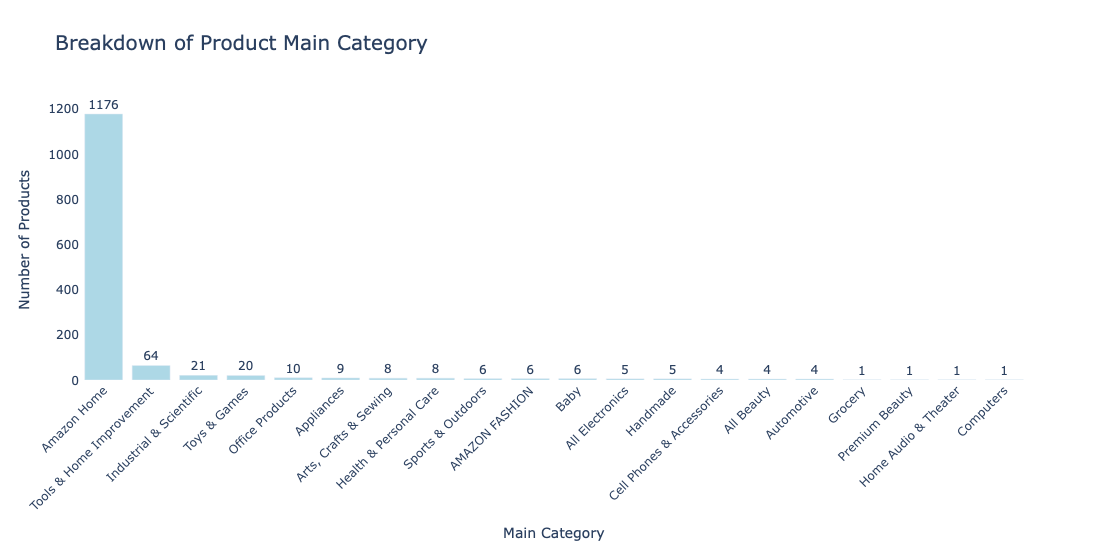

In [11]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=df["main_category"].value_counts().index,
    y=df["main_category"].value_counts(),
    marker=dict(color="lightblue"),
    text=df["main_category"].value_counts(),
    textposition="outside",
))


fig.update_layout(
    title=dict(text="Breakdown of Product Main Category", font=dict(size=20)),
    xaxis=dict(title="Main Category", tickangle=-45),
    yaxis=dict(title="Number of Products"),
    plot_bgcolor="white",
    paper_bgcolor="white",
    height=550
)

# Data Cleaning

In [12]:
df[df["title"].notna()][df[df["title"].notna()]["title"].apply(lambda x: "<" in x)]

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin


# Data Processing

The data is going to be processed and stored in our AWS Opensearch Index with the following schema and structure:
##### Main Index
```json
{
  "parent_asin": "B08N5WRWNW",
  "title": "Sony WH-1000XM4 Wireless Headphones",
  "store": "Sony",
  "main_category": "Electronics",
  "categories": ["Electronics", "Headphones", "Over-Ear Headphones"],
  "price": 279.99,
  "average_rating": 4.7,
  "rating_number": 52341,
  "features": [
    "Industry leading noise cancellation",
    "30 hour battery life",
    "Touch sensor controls"
  ],
  "description": [
    "Premium wireless headphones with best in class noise cancellation",
    "Optimized for Amazon Alexa and Google Assistant"
  ],
  "details": {
    "brand": "Sony",
    "color": "Black",
    "weight": "8.96 ounces",
    "connectivity": "Bluetooth 5.0"
  },
  "bought_together": ["B08N5WRWNW", "B07XJ8C8F5"],
  "embedding": [0.023, -0.418, 0.731, "... 1021 more values ..."]
}
```

##### Images Index
```json
{
  "parent_asin": "B08N5WRWNW",
  "variant": "MAIN",
  "pixel_size": "2000x2000",
  "description": "Black over-ear headphones shown from the front against a white background. Large cushioned ear cups with Sony branding visible on the right cup. Headband appears padded with a matte finish.",
  "embedding": [0.011, -0.302, 0.541, "... 1021 more values ..."]
}
```

##### Videos Index
```json
{
  "parent_asin": "B08N5WRWNW",
  "title": "Sony WH-1000XM4 Unboxing and Setup",
  "duration": 342,
  "user_id": "USR_A3X9KLP",
  "description": "Video shows unboxing of the headphones from retail packaging. Includes the headphones, carrying case, USB-C cable, and 3.5mm audio cable. Reviewer demonstrates pairing with an iPhone and tests noise cancellation in a busy office environment.",
  "embedding": [0.033, -0.271, 0.589, "... 1021 more values ..."]
}
```

Note: These json examples were generated using generative AI for representation purposes

### Text Data

##### Processing Text

In [13]:
def clean_value(val):
    """Convert NaN, numpy types to JSON-serializable values."""
    if val is None:
        return None
    if isinstance(val, float) and np.isnan(val):
        return None
    if isinstance(val, np.integer):
        return int(val)
    if isinstance(val, np.floating):
        return float(val)
    return val

def generate_embeddings(text):
    if not text or not text.strip():
        return None

    body = json.dumps({
        "inputText": text,
        "dimensions": 1024,
        "normalize": True
    })

    response = bedrock.invoke_model(
        body=body,
        modelId="amazon.titan-embed-text-v2:0",
        accept="application/json",
        contentType="application/json"
    )

    response_body = json.loads(response["body"].read())
    return response_body["embedding"]

def build_embedding_text(json_data):
    embedding_text = [
        json_data.get("title") or "",
        json_data.get("main_category") or "",
        " ".join(json_data.get("features") or []),
        " ".join(json_data.get("description") or []),
    ]
    return " ".join(filter(None, embedding_text))

def add_embeddings_to_data(json_data):
    embedding_text = build_embedding_text(json_data)

    embeddings = generate_embeddings(embedding_text)

    json_data["embedding"] = embeddings

    return json_data


def process_row(row):
    json_data = {
        "parent_asin":      clean_value(row.get("parent_asin")),
        "main_category":    clean_value(row.get("main_category")),
        "title":            clean_value(row.get("title")),
        "average_rating":   clean_value(row.get("average_rating")),
        "rating_number":    clean_value(row.get("rating_number")),
        "price":            clean_value(row.get("price")),
        "store":            clean_value(row.get("store")),
        "features":         row.get("features") if isinstance(row.get("features"), list) else None,
        "description":      row.get("description") if isinstance(row.get("description"), list) else clean_value(row.get("description")),
        "categories":       row.get("categories") if isinstance(row.get("categories"), list) else None,
        "details":          row.get("details") if isinstance(row.get("details"), dict) else None
    }

    json_data = add_embeddings_to_data(json_data)
    
    return json_data


In [32]:
for _, row in df.iterrows():
    json_data_row = process_row(row)
    break

Below is a function made with generative AI to display a sample json

In [15]:
def preview_json(obj, max_list_items=3, max_list_len=10):
    """Build a copy of obj with long lists/dicts abbreviated for neat display."""
    if obj is None:
        return None
    if isinstance(obj, list):
        if len(obj) <= max_list_items and (max_list_len is None or len(obj) <= max_list_len):
            return [preview_json(x, max_list_items, max_list_len) for x in obj]
        if max_list_len and len(obj) > max_list_len:
            return f"... ({len(obj)} items)"
        return [preview_json(x, max_list_items, max_list_len) for x in obj[:max_list_items]] + [f"... ({len(obj) - max_list_items} more)"]
    if isinstance(obj, dict):
        return {k: preview_json(v, max_list_items, max_list_len) for k, v in obj.items()}
    if isinstance(obj, (int, float, bool, str)):
        return obj
    # e.g. numpy array / embedding
    if hasattr(obj, "__len__") and not isinstance(obj, str):
        return f"... ({len(obj)} values)"
    return obj

display_data = preview_json(json_data_row)
print(json.dumps(display_data, indent=2, default=str))

{
  "parent_asin": "B092W84VKC",
  "main_category": "Amazon Home",
  "title": "ShineeKee Soild Wood Floating Shelves Set of 2 Wall Mounted Shelves Rustic Storage Wall Shelf Thick Natural Wood Floating Wall Shelves for Laundry Room Living Room Bedroom Kitchen Bathroom-16 x 5.5\"",
  "average_rating": 4.4,
  "rating_number": 66,
  "price": null,
  "store": "ShineeKee",
  "features": [
    "\u3010100% US HOMEGROWN PINE WOOD\u3011It can be proud to say that our wood board is 100% sourced from authentic pine wood in native American forests, exuding the fragrance of pine wood. Clear wood texture and unique craftsmanship create a retro style. Package includes 2pcs wooden shelves and necessary hardware. Each shelf measures 16\" x 5.5\" x 1.2\" inches, thick wood boards and solid brackets provide powerful load bearing capacity, can securely hold up to 40lbs, perfect for home decoration and storage.",
    "\u3010UPGRATED 2 TYPES WALL ANCHORS\u3011Unlike others' single installation that only appl

In [40]:
all_embedding_text = []
for _, row in df.iterrows():
    json_data = {
        "parent_asin":      clean_value(row.get("parent_asin")),
        "main_category":    clean_value(row.get("main_category")),
        "title":            clean_value(row.get("title")),
        "average_rating":   clean_value(row.get("average_rating")),
        "rating_number":    clean_value(row.get("rating_number")),
        "price":            clean_value(row.get("price")),
        "store":            clean_value(row.get("store")),
        "features":         row.get("features") if isinstance(row.get("features"), list) else None,
        "description":      row.get("description") if isinstance(row.get("description"), list) else clean_value(row.get("description")),
        "categories":       row.get("categories") if isinstance(row.get("categories"), list) else None,
        "details":          row.get("details") if isinstance(row.get("details"), dict) else None
    }
    embedding_text = build_embedding_text(json_data)
    all_embedding_text.append(embedding_text)

In [44]:
pd.Series([len(i) for i in all_embedding_text]).describe()

count    1500.000000
mean      943.153333
std       840.937014
min        14.000000
25%       216.500000
50%       747.000000
75%      1434.500000
max      8930.000000
dtype: float64

##### Adding to Vector DB

In [22]:
def get_opensearch_client(opensearch_url):
    credentials = boto3.Session().get_credentials()
    region = "eu-central-1"
    auth = AWSV4SignerAuth(credentials, region, "es")

    return OpenSearch(
        hosts=[{"host": opensearch_url, "port": 443}],
        http_auth=auth,
        use_ssl=True,
        verify_certs=True,
        connection_class=RequestsHttpConnection,
        pool_maxsize=20
    )

def push_data_to_opensearch(client, processed_data):
    actions = []
    
    for document in processed_data:
        actions.append({
            "_index": MAIN_INDEX_NAME,
            "_id": document.get("parent_asin"),
            "_source": document
        })
    
    if actions:
        success, errors = bulk(client, actions, raise_on_error=False)
        print(f"Indexed: {success} | Failed: {len(errors)}")

In [23]:
opensearch_client = get_opensearch_client(OPENSEARCH_ENDPOINT.replace("https://", ""))

In [58]:
processed_data = []
for _, row in df.iterrows():
    json_data_row = process_row(row)
    processed_data.append(json_data_row)
    break

In [59]:
push_data_to_opensearch(opensearch_client, processed_data)

Indexed: 1 | Failed: 0


#### Image Data

In [72]:
def describe_image(image_url):
    image_data = base64.b64encode(httpx.get(image_url).content).decode("utf-8")

    body = json.dumps({
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "image": {
                            "format": "jpeg",
                            "source": {
                                "bytes": image_data
                            }
                        }
                    },
                    {
                        "text": "Describe this product image in detail. Focus on what the product looks like, its colors, materials, and any notable visual features."
                    }
                ]
            }
        ],
    })

    response = bedrock.invoke_model(
        body=body,
        modelId="eu.amazon.nova-lite-v1:0",
        accept="application/json",
        contentType="application/json"
    )

    response_body = json.loads(response["body"].read())
    return response_body["output"]["message"]["content"][0]["text"]

In [73]:
describe_image(df["images"][0][0]['large'])

'The image showcases a pair of rustic wooden shelves against a plain white background. Each shelf is crafted from weathered wood, giving it a natural and earthy appearance with visible grain patterns. The shelves are supported by sleek, black metal brackets that add a modern contrast to the wooden aesthetic. \n\nOn the top shelf, there is a framed picture with a black border, displaying a photograph of a person in an indoor setting. The picture adds a personal touch and complements the rustic theme of the shelves. \n\nThe lower shelf features a wooden figurine of a bear playing a guitar, adding a whimsical and charming element to the setup. The figurine is placed on a small, natural-colored log, enhancing the rustic feel. \n\nNext to the figurine, there is a white ceramic vase with a minimalist design. The vase contains a small bouquet of flowers, consisting of red and white blooms, which provides a splash of color and freshness to the overall arrangement. \n\nThe arrangement of the it

In [88]:
def build_image_json_data(row, image_data):
    parent_asin = row["parent_asin"]
    variant = image["variant"]
    image_description = describe_image(image["large"])
    image_description_embeddings = generate_embeddings(image_description)
    
    return {
        "parent_asin": parent_asin,
        "variant": variant,
        "description": image_description,
        "embedding": image_description_embeddings
    }

In [89]:
for _, row in df[df["images"].notna()].iterrows():
    for image_data in row["images"]:

        parent_asin = row["parent_asin"]
        variant = image_data["variant"]
        image_description = describe_image(image["large"])

        
        image_json_data = build_image_json_data(row, image_data)
        
        break
    break

In [91]:
def push_data_to_opensearch(client, index_name, processed_data):
    actions = []
    
    for document in processed_data:
        actions.append({
            "_index": index_name,
            "_id": document.get("parent_asin"),
            "_source": document
        })
    
    if actions:
        success, errors = bulk(client, actions, raise_on_error=False)
        print(f"Indexed: {success} | Failed: {len(errors)}")

In [93]:
push_data_to_opensearch(opensearch_client, "products_images", [image_json_data])

Indexed: 1 | Failed: 0


#### Video Data

# Rag System Calling

In [17]:
def query_text_index(question, top_k= 5):
    """Search the main product index using vector similarity."""
    embedding = generate_embeddings(question)

    response = opensearch_client.search(
        index=MAIN_INDEX_NAME,
        body={
            "size": top_k,
            "query": {
                "knn": {
                    "embedding": {
                        "vector": embedding,
                        "k": top_k
                    }
                }
            },
            "_source": ["parent_asin", "title", "main_category", "price", "average_rating", "features", "description"]
        }
    )

    hits = response["hits"]["hits"]
    if not hits:
        return "No products found."

    results = []
    for hit in hits:
        src = hit["_source"]
        results.append(
            f"ASIN: {src.get('parent_asin')} | {src.get('title')} | "
            f"${src.get('price', 'N/A')} | Rating: {src.get('average_rating')} | "
            f"Features: {', '.join(src.get('features') or [])} | "
            f"Description: {src.get('description')}"
        )
    return "\n".join(results)


def query_image_index(question, top_k= 5):
    """Search the image index using vector similarity."""
    embedding = generate_embeddings(question)

    response = opensearch_client.search(
        index=IMAGE_INDEX_NAME,
        body={
            "size": top_k,
            "query": {
                "knn": {
                    "embedding": {
                        "vector": embedding,
                        "k": top_k
                    }
                }
            },
            "_source": ["parent_asin", "variant", "description"]
        }
    )

    hits = response["hits"]["hits"]
    if not hits:
        return "No images found."

    results = []
    for hit in hits:
        src = hit["_source"]
        results.append(
            f"ASIN: {src.get('parent_asin')} | Variant: {src.get('variant')} | "
            f"Image: {src.get('description')}"
        )
    return "\n".join(results)

In [18]:
tools = [
    {
        "name": "query_text_index",
        "description": "Search the product catalogue using a question. Returns matching products with titles, prices, ratings and features.",
        "input_schema": {
            "type": "object",
            "properties": {
                "question": {
                    "type": "string",
                    "description": "The search query or question about products"
                }
            },
            "required": ["question"]
        }
    },
    {
        "name": "query_image_index",
        "description": "Search product images using a question. Returns matching images with visual descriptions. Use this when the question is about appearance, colour, design or visuals.",
        "input_schema": {
            "type": "object",
            "properties": {
                "question": {
                    "type": "string",
                    "description": "The search query about product appearance or visuals"
                }
            },
            "required": ["question"]
        }
    }
]

In [19]:
def run_tool(tool_name, tool_input):
    if tool_name == "query_text_index":
        return query_text_index(tool_input["question"])
    elif tool_name == "query_image_index":
        return query_image_index(tool_input["question"])
    else:
        return f"Unknown tool: {tool_name}"

In [26]:
def send_message(user_message):
    """Send a message to the agent and return its final response."""
    messages = [{"role": "user", "content": [{"text": user_message}]}]

    while True:
        response = bedrock.invoke_model(
            modelId=AGENT_MODEL,
            contentType="application/json",
            accept="application/json",
            body=json.dumps({
                "schemaVersion": "messages-v1",
                "system": [{
                    "text": (
                        "You are a helpful product shopping assistant. "
                        "Use the tools available to search the product catalogue. "
                        "You may call tools multiple times to gather all necessary information. "
                        "When you have enough information, respond with ONLY the final answer, no preamble, no reasoning, no tool call summaries. "
                        "Be concise and direct."
                    )
                }],
                "messages": messages,
                "toolConfig": {
                    "tools": [
                        {
                            "toolSpec": {
                                "name": tool["name"],
                                "description": tool["description"],
                                "inputSchema": {"json": tool["input_schema"]}
                            }
                        }
                        for tool in tools
                    ]
                },
                "inferenceConfig": {
                    "maxTokens": 1024
                }
            })
        )

        response_body = json.loads(response["body"].read())
        output_message = response_body["output"]["message"]
        stop_reason = response_body["stopReason"]
        content = output_message["content"]

        messages.append({"role": "assistant", "content": content})

        if stop_reason == "end_turn":
            return next((block["text"] for block in content if "text" in block), "")

        if stop_reason == "tool_use":
            tool_results = []
            for block in content:
                if "toolUse" in block:
                    tool_use = block["toolUse"]
                    result = run_tool(tool_use["name"], tool_use["input"])
                    tool_results.append({
                        "toolResult": {
                            "toolUseId": tool_use["toolUseId"],
                            "content": [{"text": result}]
                        }
                    })
            messages.append({"role": "user", "content": tool_results})

In [30]:
send_message("do you have any brown shelves?")

WARNING	Task(Task-3) opensearch:base.py:log_request_fail()- POST https://search-bshgrag-db-fzguhm6xbhftvsxrphne6jnnpe.eu-central-1.es.amazonaws.com:443/products_main/_search [status:N/A request:10.005s]
 Traceback (most recent call last):
   File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/urllib3/connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
               ^^^^^^^^^^^^^^^^^^
   File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/urllib3/connection.py", line 516, in getresponse
    httplib_response = super().getresponse()
                       ^^^^^^^^^^^^^^^^^^^^^
   File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/http/client.py", line 1430, in getresponse
    response.begin()
   File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/http/client.py", line 331, in begin
    version, status, reason = self._read_status()
                     

ConnectionTimeout: ConnectionTimeout caused by - ReadTimeout(HTTPSConnectionPool(host='search-bshgrag-db-fzguhm6xbhftvsxrphne6jnnpe.eu-central-1.es.amazonaws.com', port=443): Read timed out. (read timeout=10))